==== Best KNN Params ====
{'clf__metric': 'minkowski', 'clf__n_neighbors': 3, 'clf__p': 2, 'clf__weights': 'uniform'}

==== KNN Performance (CV OOF) ====
Confusion Matrix:
 [[5 0]
 [0 5]]
              precision    recall  f1-score   support

           0      1.000     1.000     1.000         5
           1      1.000     1.000     1.000         5

    accuracy                          1.000        10
   macro avg      1.000     1.000     1.000        10
weighted avg      1.000     1.000     1.000        10

ROC-AUC: 1.0

==== Best Decision Tree Params ====
{'clf__max_depth': 2, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2}

==== Decision Tree Performance (CV OOF) ====
Confusion Matrix:
 [[5 0]
 [1 4]]
              precision    recall  f1-score   support

           0      0.833     1.000     0.909         5
           1      1.000     0.800     0.889         5

    accuracy                          0.900        10
   macro avg      0.917     0.900     0.899        10
weig

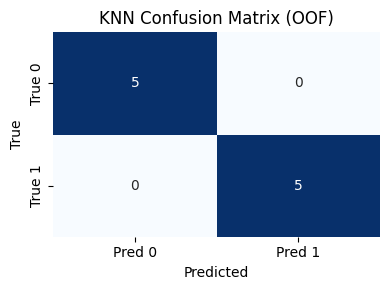

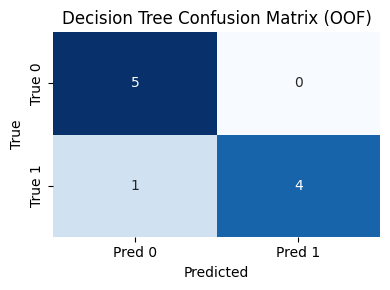

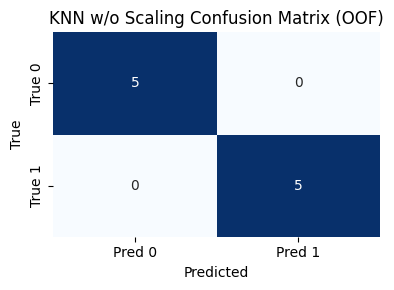

In [ ]:
# =========================
# Loan Default Prediction with KNN (and Decision Tree comparison)
# Mixed numeric/categorical features, class-imbalance-aware evaluation
# =========================

# 1) Imports
import pandas as pd
import numpy as np
from io import StringIO

from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score
)
import matplotlib.pyplot as plt
import seaborn as sns

# 2) Data (embedded from your prompt)
csv_text = """Age,AnnualIncome,CreditScore,LoanAmount,LoanTerm,EmploymentType,loan
28,6.5,720,5,5,Salaried,0
45,12,680,10,10,Self-Employed,1
35,8,750,6,7,Salaried,0
50,15,640,12,15,Self-Employed,1
30,7,710,5,5,Salaried,0
42,10,660,9,10,Salaried,1
26,5.5,730,4,4,Salaried,0
48,14,650,11,12,Self-Employed,1
38,9,700,7,8,Salaried,0
55,16,620,13,15,Self-Employed,1
"""

df = pd.read_csv(StringIO(csv_text))
X = df.drop(columns=["loan"])
y = df["loan"]

num_features = ["Age","AnnualIncome","CreditScore","LoanAmount","LoanTerm"]
cat_features = ["EmploymentType"]

# 3) Preprocessing: scale numeric, one-hot categorical
numeric_tf = Pipeline([("scaler", StandardScaler())])
categorical_tf = OneHotEncoder(handle_unknown="ignore")

preprocess = ColumnTransformer([
    ("num", numeric_tf, num_features),
    ("cat", categorical_tf, cat_features)
])

# 4) KNN pipeline + hyperparameter tuning (class-imbalance aware scoring)
knn = KNeighborsClassifier()
pipe_knn = Pipeline([("prep", preprocess), ("clf", knn)])

param_grid_knn = {
    "clf__n_neighbors": list(range(1, 8)),
    "clf__weights": ["uniform","distance"],
    "clf__metric": ["minkowski"],
    "clf__p": [1,2],  # Manhattan vs Euclidean
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_knn = GridSearchCV(
    pipe_knn, param_grid_knn, cv=cv, scoring="f1", n_jobs=None, refit=True
)
grid_knn.fit(X, y)
best_knn = grid_knn.best_estimator_

# 5) Out-of-fold predictions (fairer evaluation on tiny dataset)
pred_knn = cross_val_predict(best_knn, X, y, cv=cv)
proba_knn = cross_val_predict(best_knn, X, y, cv=cv, method="predict_proba")[:,1]

cm_knn = confusion_matrix(y, pred_knn)
report_knn = classification_report(y, pred_knn, digits=3)
roc_knn = roc_auc_score(y, proba_knn)

# 6) Decision Tree pipeline for comparison
pipe_dt = Pipeline([
    ("prep", preprocess),
    ("clf", DecisionTreeClassifier(random_state=42))
])

param_grid_dt = {
    "clf__max_depth": [2,3,4,None],
    "clf__min_samples_split": [2,3,4],
    "clf__min_samples_leaf": [1,2],
}
grid_dt = GridSearchCV(
    pipe_dt, param_grid_dt, cv=cv, scoring="f1", refit=True
)
grid_dt.fit(X, y)
best_dt = grid_dt.best_estimator_
pred_dt = cross_val_predict(best_dt, X, y, cv=cv)
proba_dt = cross_val_predict(best_dt, X, y, cv=cv, method="predict_proba")[:,1]
cm_dt = confusion_matrix(y, pred_dt)
report_dt = classification_report(y, pred_dt, digits=3)
roc_dt = roc_auc_score(y, proba_dt)

# 7) Demonstrate feature dominance (NO SCALING) – bad practice for KNN
preprocess_unscaled = ColumnTransformer([
    ("num", "passthrough", num_features),
    ("cat", categorical_tf, cat_features),
])
pipe_knn_unscaled = Pipeline([
    ("prep", preprocess_unscaled),
    ("clf", KNeighborsClassifier(n_neighbors=3))
])
pred_knn_unscaled = cross_val_predict(pipe_knn_unscaled, X, y, cv=cv)
cm_knn_unscaled = confusion_matrix(y, pred_knn_unscaled)

# 8) Print results
print("==== Best KNN Params ====")
print(grid_knn.best_params_)
print("\n==== KNN Performance (CV OOF) ====")
print("Confusion Matrix:\n", cm_knn)
print(report_knn)
print("ROC-AUC:", round(roc_knn, 3))

print("\n==== Best Decision Tree Params ====")
print(grid_dt.best_params_)
print("\n==== Decision Tree Performance (CV OOF) ====")
print("Confusion Matrix:\n", cm_dt)
print(report_dt)
print("ROC-AUC:", round(roc_dt, 3))

print("\n==== KNN WITHOUT SCALING (for illustration) ====")
print("Confusion Matrix:\n", cm_knn_unscaled)

# 9) Quick pattern insights
print("\n==== Quick Pattern Insights from Sample ====")
print("Default rate by EmploymentType:")
print(df.groupby("EmploymentType")["loan"].mean())
print("\nAverages by class (0 = non-default, 1 = default):")
print(df.groupby("loan")[num_features].mean())

# 10) Optional: Confusion matrix heatmaps
def plot_cm(cm, title):
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Pred 0','Pred 1'], yticklabels=['True 0','True 1'])
    plt.title(title)
    plt.ylabel('True'); plt.xlabel('Predicted')
    plt.tight_layout(); plt.show()

plot_cm(cm_knn, "KNN Confusion Matrix (OOF)")
plot_cm(cm_dt, "Decision Tree Confusion Matrix (OOF)")
plot_cm(cm_knn_unscaled, "KNN w/o Scaling Confusion Matrix (OOF)")
